Análisis de Datos CSV CORRELACIÓN

Importar librerías

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CARGAR ARCHIVO CSV

In [2]:
url_correlacion = "https://raw.githubusercontent.com/eduardorivas2517502022/Parcial4-RivasEduardo-2517502022/refs/heads/main/csv/clave_G_correlacion.csv"

df_correlacion = pd.read_csv(url_correlacion)

df_correlacion.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,G-C0001,36,1333,12,73.69,7.34,1,10,18.10,830.56
1,G-C0002,38,1318,11,107.75,8.31,1,10,21.55,998.80
2,G-C0003,40,1105,9,75.72,5.89,7,7,17.82,563.19
3,G-C0004,34,1349,6,60.43,7.41,1,4,24.88,353.01
4,G-C0005,52,1073,2,60.52,6.61,3,0,26.30,143.68


REVISAR ESTRUCTURA DEL DATASET

In [3]:
df_correlacion.info()
df_correlacion.isnull().sum()
df_correlacion.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          251 non-null    object 
 1   edad                251 non-null    int64  
 2   ingresos_mensuales  251 non-null    int64  
 3   frecuencia_compra   251 non-null    int64  
 4   ticket_promedio     250 non-null    float64
 5   satisfaccion        250 non-null    float64
 6   reclamos            251 non-null    int64  
 7   uso_app             251 non-null    int64  
 8   tiempo_respuesta    250 non-null    float64
 9   consumo_total       251 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 19.7+ KB


np.int64(1)

Muestra estadisticas generales, nombra columnas, selecciona variables numericas y Convierte datos numéricos correctamente

In [9]:
df_correlacion.describe()
df_correlacion.columns
variables_numericas = df_correlacion.select_dtypes(
    include=['int64', 'float64']
)

variables_numericas = variables_numericas.apply(
    pd.to_numeric,
    errors='coerce'
)

Reemplazar valores nulos

In [10]:
variables_numericas = variables_numericas.fillna(
    variables_numericas.mean()
)

Calcula matriz de correlación

In [11]:
matriz_correlacion = variables_numericas.corr()

matriz_correlacion

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,0.046354,-0.001589,0.226554,-0.095200,0.132463,-0.022369,0.126707,0.069585
ingresos_mensuales,0.046354,1.000000,0.109448,0.519870,0.005542,-0.053131,-0.051252,-0.020264,0.312249
frecuencia_compra,-0.001589,0.109448,1.000000,0.066125,0.241467,-0.151309,0.521483,-0.200047,0.876545
ticket_promedio,0.226554,0.519870,0.066125,1.000000,-0.047622,0.058212,0.040723,0.124876,0.459190
satisfaccion,-0.095200,0.005542,0.241467,-0.047622,1.000000,-0.822087,0.224039,-0.665824,0.319124
reclamos,0.132463,-0.053131,-0.151309,0.058212,-0.822087,1.000000,-0.006681,0.599195,-0.231863
uso_app,-0.022369,-0.051252,0.521483,0.040723,0.224039,-0.006681,1.000000,-0.139125,0.543565
tiempo_respuesta,0.126707,-0.020264,-0.200047,0.124876,-0.665824,0.599195,-0.139125,1.000000,-0.224878
consumo_total,0.069585,0.312249,0.876545,0.459190,0.319124,-0.231863,0.543565,-0.224878,1.000000


Crea mapa de calor

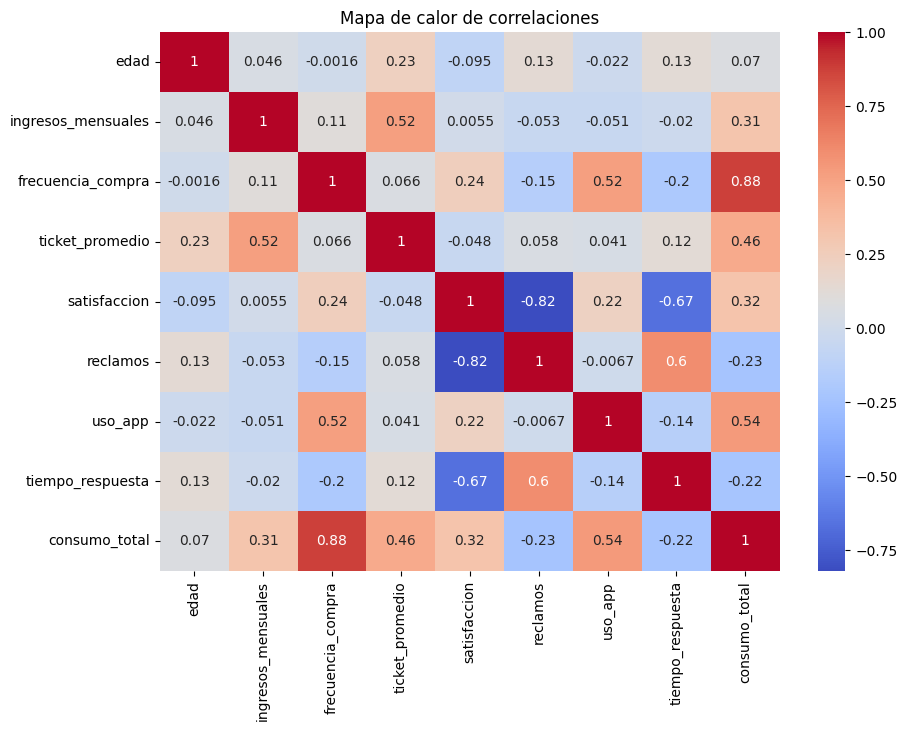

In [12]:
plt.figure(figsize=(10,7))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='coolwarm'
)

plt.title('Mapa de calor de correlaciones')

plt.show()

Muestra correlaciones positivas más importantes

In [13]:
correlaciones_positivas = matriz_correlacion.unstack()

correlaciones_positivas = correlaciones_positivas.sort_values(
    ascending=False
)

correlaciones_positivas = correlaciones_positivas[
    correlaciones_positivas < 1
]

correlaciones_positivas.head(10)

,,0
frecuencia_compra,consumo_total,0.876545
consumo_total,frecuencia_compra,0.876545
tiempo_respuesta,reclamos,0.599195
reclamos,tiempo_respuesta,0.599195
uso_app,consumo_total,0.543565
consumo_total,uso_app,0.543565
frecuencia_compra,uso_app,0.521483
uso_app,frecuencia_compra,0.521483
ingresos_mensuales,ticket_promedio,0.519870
ticket_promedio,ingresos_mensuales,0.519870


Muestra correlaciones negativas más importantes

In [14]:
correlaciones_negativas = matriz_correlacion.unstack()

correlaciones_negativas = correlaciones_negativas.sort_values()

correlaciones_negativas.head(10)

reclamos           satisfaccion        -0.822087
satisfaccion       reclamos            -0.822087
                   tiempo_respuesta    -0.665824
tiempo_respuesta   satisfaccion        -0.665824
consumo_total      reclamos            -0.231863
reclamos           consumo_total       -0.231863
tiempo_respuesta   consumo_total       -0.224878
consumo_total      tiempo_respuesta    -0.224878
frecuencia_compra  tiempo_respuesta    -0.200047
tiempo_respuesta   frecuencia_compra   -0.200047
dtype: float64